In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt


# Data generation - 1D linear advection equation with discontinuity midpoint

$$
\partial_t u(x, t) + c \cdot \partial_x u(x, t) = 0
$$

* periodic spatial domain: $x \in [0, 2]$
* spatial resolution: $N_x = 1000$
* fixed advection speed: $c = 1$
* initial condition: single rectangular pulse $u_0$
    - pulse height: $h \in [0.2, 0.8]$
    - pulse width: $w \in [0.05, 0.3]$
* solution: analytic solution $u(x, t) = u_0(x - ct)$
* tracked discontinuity for later cutting/lifting: pulse midpoint between the $0 \to h$ and $h \to 0$ jumps
* no spatial points are removed
* final time: $T = 1$
* temporal resolution: $N_t = 1000$


In [ ]:
# ------------------------- PDE, grid and storage settings -------------------------
L = 1
c = 1.0                      # fixed advection speed
T = 0.25
Nx = 500
Nt = 15
x = np.linspace(0.0, L, Nx, endpoint=False, dtype=np.float64)
t = np.linspace(0.0, T, Nt, dtype=np.float64)

# Parameter box for discontinuous rectangular pulses.
height_range = [0.2, 0.8]   
width_range  = [0.2, 0.45]
shift_range  = [0.1, 0.2]

In [ ]:
# ------------------------- Random pulse parameters ------------------------
def random_pulse_parameters(N, height_range=height_range, width_range=width_range, shift_range=shift_range):
    seed = 42
    rng = np.random.default_rng(seed)

    # Discrete parameter grids
    h_vals = np.round(np.arange(height_range[0], height_range[1] + 0.01, 0.02), 2)
    w_vals = np.round(np.arange(width_range[0], width_range[1] + 0.01, 0.02), 2)
    s_vals = np.round(np.arange(shift_range[0], shift_range[1] + 0.1, 0.02), 2)

    n_h = len(h_vals)           # 13
    n_w = len(w_vals)           # 13
    n_s = len(s_vals)           # 6
    n_total = n_h * n_w * n_s   # 2418

    # print(n_h)
    # print(n_w)
    # print(n_s)
    # print(n_total)

    # Sample unique flat indices uniformly
    flat_idx = rng.choice(n_total, size=N, replace=False)

    # Map flat indices to (h, w, s) indices
    h_idx = flat_idx // (n_w * n_s)
    rem = flat_idx % (n_w * n_s)
    w_idx = rem // n_s
    s_idx = rem % n_s

    # Get parameter values
    h = h_vals[h_idx].astype(np.float32)
    w = w_vals[w_idx].astype(np.float32)
    s = s_vals[s_idx].astype(np.float32)

    params = np.stack([h, w, s], axis=1)

    return params


# ------------------------- Initial condition ------------------------
def initial_condition_u0(params, x=x, Nx=Nx):
    # params[:, 0] = h, params[:, 1] = w, params[:, 2] = s
    h = params[:, 0:1]   # shape (N, 1)
    w = params[:, 1:2]   # shape (N, 1)
    s = params[:, 2:3]   # shape (N, 1)

    # Allocate u0 with shape (N, Nx)
    u0 = np.zeros((params.shape[0], Nx), dtype=np.float32)

    # For each sample n, set u0[n, j] = h[n] if x[j] in (s[n], s[n] + w[n])
    mask = (x[None, :] > s) & (x[None, :] < (s + w))
    u0[mask] = np.broadcast_to(h, (params.shape[0], Nx))[mask]

    return u0


# ------------------------- Exact solution for linear advection ------------------------
def linear_advection_solution(params, x=x, c=c, t=t, L=L, Nt=Nt, Nx=Nx):
    # params[:, 0] = h, params[:, 1] = w, params[:, 2] = s
    h = params[:, 0][:, None, None]   # shape (N, 1, 1)
    w = params[:, 1][:, None, None]   # shape (N, 1, 1)
    s = params[:, 2][:, None, None]   # shape (N, 1, 1)

    # Backtracked position for the exact periodic solution:
    # u(x, t) = u_0((x - c t) mod L)
    x_shifted = (x[None, None, :] - c * t[None, :, None]) % L

    # Allocate solution with shape (N, Nt, Nx)
    u = np.zeros((params.shape[0], Nt, Nx), dtype=np.float32)

    # For each sample n and time k, set u[n, k, j] = h[n]
    # if x_shifted[n, k, j] in (s[n], s[n] + w[n])
    mask = (x_shifted > s) & (x_shifted < (s + w))
    u[mask] = np.broadcast_to(h, (params.shape[0], Nt, Nx))[mask]

    return u


# ------------------------- Exact discontinuity trajectories ------------------------
def discontinuity_locations(params, t=t, c=c, L=L, x=x):
    dx = x[1] - x[0]
    s = params[:, 2][:, None]
    w = params[:, 1][:, None]

    x_left = (s + c * t[None, :] + 0.5 * dx) % L
    x_right = (s + c * t[None, :] + w + 0.5 * dx) % L

    discontinuities = np.stack([x_left, x_right], axis=-1)

    return discontinuities.astype(np.float32)  # (N, Nt, 2)


# ------------------------- Fixed train / val / test split ------------------------
def train_val_test_split(N, seed=42):
    rng = np.random.default_rng(seed)
    all_idx = np.arange(N)
    rng.shuffle(all_idx)

    train_idx = all_idx[:450]
    val_idx = all_idx[450:480]
    test_idx = all_idx[480:500]

    return train_idx, val_idx, test_idx


In [ ]:
# ------------------------ Generate dataset ------------------------
N = 500 # ≈20% coverage

params = random_pulse_parameters(N)
u0 = initial_condition_u0(params)
u = linear_advection_solution(params)
discontinuities = discontinuity_locations(params)
x_extended = np.broadcast_to(x[None, None, :], (N, Nt, Nx)).astype(np.float32).copy()

train_idx, val_idx, test_idx = train_val_test_split(N)

np.savez_compressed(
    f"linear_advection_dataset_N_{N}.npz",
    params=params,                      # (N, 3)
    u0=u0,                              # (N, Nx)
    u=u,                                # (N, Nt, Nx)
    discontinuities=discontinuities,    # (N, Nt, 2)
    x_extended=x_extended,              # (N, Nt, Nx)
    x=x,                                # (Nx,)
    t=t,                                # (Nt,)
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx
)

print(f"dx = {x[1] - x[0]}")
print(f"dt = {t[1] - t[0]}")

print(params.shape)
print(u0.shape)
print(u.shape)
print(discontinuities.shape)
print(x.shape)
print(x_extended.shape)
print(train_idx.shape, val_idx.shape, test_idx.shape)


dx = 0.002
dt = 0.017857142857142856
(500, 3)
(500, 500)
(500, 15, 500)
(500, 15, 2)
(500,)
(500, 15, 500)
(450,) (30,) (20,)


## Plotting

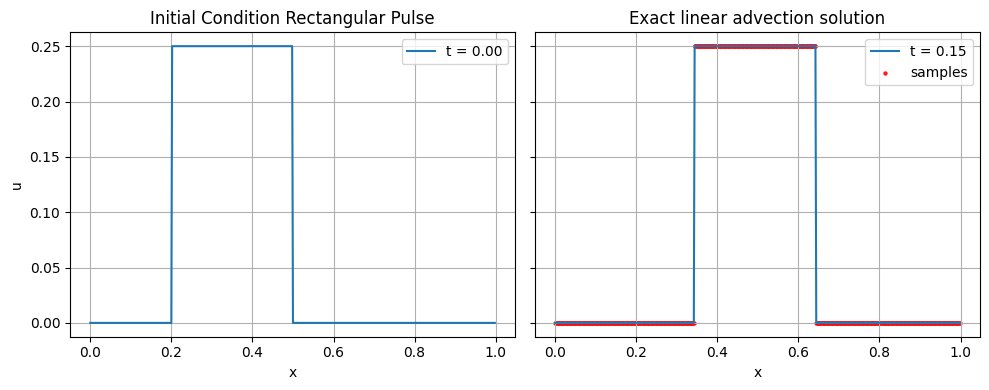

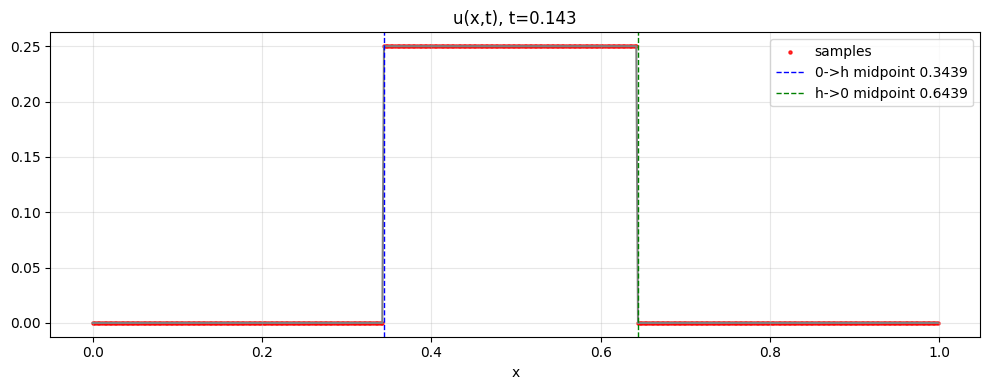

In [15]:
def plot_solution(x, u_0, u_t, t_plot, dt):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    ax1.plot(x, u_0, label="t = 0.00")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u")
    ax1.set_title("Initial Condition Rectangular Pulse")
    ax1.legend()
    ax1.grid()

    ax2.plot(x, u_t[int(t_plot/dt)], label="t = %.2f" % t_plot)
    ax2.scatter(x, u_t[int(t_plot/dt)], color='red', s=5, label="samples", alpha=0.8)
    ax2.set_xlabel("x")
    ax2.set_title("Exact linear advection solution")
    ax2.legend()
    ax2.grid()

    plt.tight_layout()
    plt.show()

def plotting_discontinuity_area(x, u_t, x_discontinuity, t_plot, dt):
    k = min(int(t_plot / dt), len(u_t) - 1)

    plt.figure(figsize=(10, 4))
    plt.plot(x, u_t[k], color="gray")
    plt.scatter(x, u_t[k], color="red", s=5, alpha=0.8, label="samples")
    plt.axvline(x_discontinuity[k, 0], color='blue', linestyle='--', linewidth=1, label=f"0->h midpoint {x_discontinuity[k, 0]:.4f}")
    plt.axvline(x_discontinuity[k, 1], color='green', linestyle='--', linewidth=1, label=f"h->0 midpoint {x_discontinuity[k, 1]:.4f}")
    plt.title(f"u(x,t), t={k*dt:.3f}")
    plt.xlabel("x")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

t_plot = 0.15
plot_solution(x, u0[0], u[0], t_plot=t_plot, dt=t[1] - t[0])
plotting_discontinuity_area(x, u[0], discontinuities[0], t_plot=t_plot, dt=t[1] - t[0])
